In [1]:
from models.unet import UNetModel
from tools.seed_everything import seed_everything
from tools.segy_dataset import SegyDataset, ClipFirstChannel, SliceLastDim
import torch
from matplotlib import pyplot as plt
from torchvision import transforms

In [2]:
seed_everything(42)

In [3]:
def count_params(model: torch.nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen

In [4]:
MODEL_CONFIGS = {
    "simple": {
        "in_channels": 1,
        "model_channels": 32,
        "out_channels": 1,
        "num_res_blocks": 2,
        "attention_resolutions": [2],
        "dropout": 0.2,
        "channel_mult": [1, 1, 2],
        "conv_resample": False,
        "dims": 2,
        "num_classes": None,
        "use_checkpoint": False,
        "num_heads": 1,
        "num_head_channels": -1,
        "num_heads_upsample": -1,
        "use_scale_shift_norm": True,
        "resblock_updown": False,
        "use_new_attention_order": True,
        "with_fourier_features": False,
    },
}

model = UNetModel(**MODEL_CONFIGS["simple"])

total, trainable, frozen = count_params(model)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Frozen params:    {frozen:,}")

Total params:     1,140,065
Trainable params: 1,140,065
Frozen params:    0


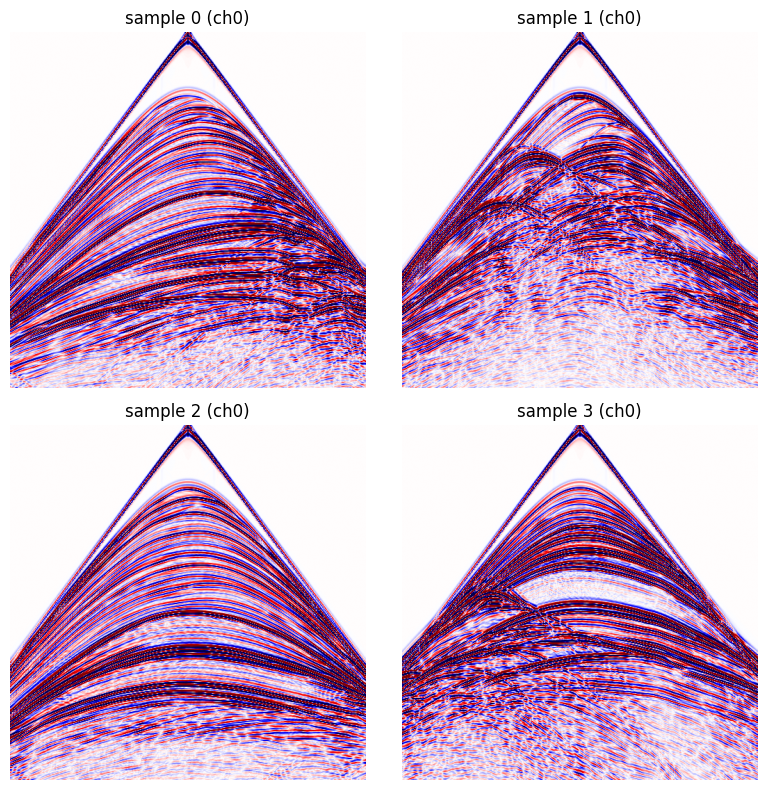

In [5]:
transform = transforms.Compose([
    SliceLastDim(0, 1501),
    ClipFirstChannel(-2, 2),
    transforms.Resize((512, 512)),
])
dataset = SegyDataset("ma2+GathAP.sgy", transform=transform)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)
x = next(iter(dataloader))

imgs = x[:, 0]  # [B,H,W]
imgs = imgs.detach().cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()
for i in range(4):
    axes[i].imshow(imgs[i].T, cmap="seismic", origin="upper", vmin=-1, vmax=1)
    axes[i].set_title(f"sample {i} (ch0)")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
samples = x[:, 0].unsqueeze(1)

t = torch.torch.rand(samples.shape[0])
y = model(samples, t, {})
print(y.shape)